In [ ]:
# !pip install transformers datasets torch tqdm pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 5.0 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 4.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 5.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 5.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 4.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 5.5 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 5.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 4.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [transformers] [transformers]ub]


In [2]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForMaskedLM
from tqdm import tqdm

/home/pratishtha/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 10171.92it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [4]:
dataset = load_dataset("winogrande", "winogrande_s", split="train")

# sample ~300
dataset = dataset.shuffle(seed=42).select(range(300))

df = pd.DataFrame(dataset)
df.head()

Generating validation split: 100%|██████████| 1267/1267 [00:00<00:00, 356083.03 examples/s]


,sentence,option1,option2,answer
0,The dog's hair had to be removed after it got ...,mud,hair,2
1,Megan enjoyed summer while Felicia did not. _...,Megan,Felicia,1
2,"Jessica often experiences severe nausea, Victo...",Jessica,Victoria,2
3,"Jack loved math and disliked social sciences, ...",math,sociology,1
4,Monica enjoyed watching Western films while Na...,Monica,Natalie,2


In [5]:
def construct_sentences(row):
    sent = row["sentence"]
    option1 = row["option1"]
    option2 = row["option2"]

    sent1 = sent.replace("_", option1)
    sent2 = sent.replace("_", option2)

    return sent1, sent2

In [6]:
def compute_pll(sentence):
    tokens = tokenizer.tokenize(sentence)
    input_ids = tokenizer.encode(sentence, return_tensors="pt").to(device)

    pll = 0.0

    for i in range(1, input_ids.size(1) - 1):
        masked_input = input_ids.clone()
        masked_input[0, i] = tokenizer.mask_token_id

        with torch.no_grad():
            outputs = model(masked_input)
            logits = outputs.logits

        log_probs = torch.log_softmax(logits, dim=-1)
        token_id = input_ids[0, i]

        pll += log_probs[0, i, token_id].item()

    return pll

In [7]:
results = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    sent1, sent2 = construct_sentences(row)

    pll1 = compute_pll(sent1)
    pll2 = compute_pll(sent2)

    pred = 1 if pll1 > pll2 else 2
    correct = int(pred == int(row["answer"]))

    results.append({
        "sentence": row["sentence"],
        "option1": row["option1"],
        "option2": row["option2"],
        "pll1": pll1,
        "pll2": pll2,
        "prediction": pred,
        "answer": int(row["answer"]),
        "correct": correct
    })

results_df = pd.DataFrame(results)

100%|██████████| 300/300 [11:29<00:00,  2.30s/it]


In [8]:
accuracy = results_df["correct"].mean()
print(f"Baseline Accuracy: {accuracy:.3f}")

Baseline Accuracy: 0.577


In [9]:
# Example: synonym replacement (basic placeholder)
def perturb_synonym(sentence):
    return sentence.replace("big", "large").replace("small", "tiny")

# Example: adjective polarity flip
def perturb_polarity(sentence):
    return sentence.replace("good", "bad").replace("bad", "good")

# Example: structural tweak
def perturb_structure(sentence):
    return sentence.replace("because", "as")

In [10]:
def evaluate_with_perturbation(row, perturb_fn):
    sent1, sent2 = construct_sentences(row)

    p_sent1 = perturb_fn(sent1)
    p_sent2 = perturb_fn(sent2)

    pll1 = compute_pll(p_sent1)
    pll2 = compute_pll(p_sent2)

    return 1 if pll1 > pll2 else 2

In [11]:
changes = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    original_pred = results_df.loc[_]["prediction"]

    perturbed_pred = evaluate_with_perturbation(row, perturb_synonym)

    changed = int(original_pred != perturbed_pred)

    changes.append(changed)

results_df["perturb_change"] = changes

100%|██████████| 300/300 [11:59<00:00,  2.40s/it]


In [12]:
change_rate = results_df["perturb_change"].mean()
print(f"Prediction Change Rate: {change_rate:.3f}")

Prediction Change Rate: 0.003


In [13]:
errors = results_df[results_df["correct"] == 0]

print("Total Errors:", len(errors))
errors.head()

Total Errors: 127


,sentence,option1,option2,pll1,pll2,prediction,answer,correct,perturb_change
0,The dog's hair had to be removed after it got ...,mud,hair,-28.013988,-33.843885,1,2,0,0
1,Megan enjoyed summer while Felicia did not. _...,Megan,Felicia,-34.469601,-29.460223,2,1,0,0
2,"Jessica often experiences severe nausea, Victo...",Jessica,Victoria,-67.273396,-70.357494,1,2,0,0
5,Lawrence made a bowl at the pottery store and ...,Lawrence,Randy,-46.690048,-40.677908,2,1,0,0
10,Heather bought a doll for her daughters cradle...,cradle,doll,-55.279976,-48.407155,2,1,0,0


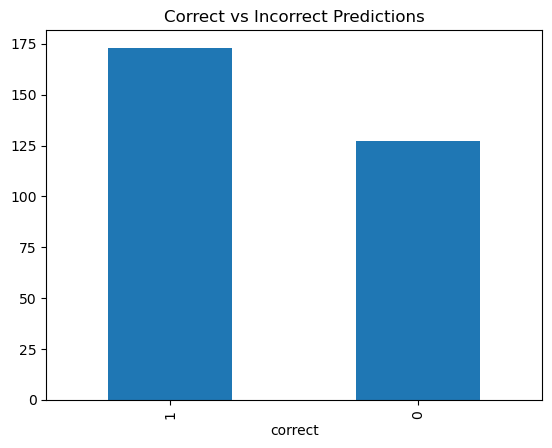

In [14]:
import matplotlib.pyplot as plt

results_df["correct"].value_counts().plot(kind="bar")
plt.title("Correct vs Incorrect Predictions")
plt.show()